# Where Should WA Put Its Next Community Resource Centre?

**A regional engagement resource-allocation model for Western Australia**

Given a limited budget, which WA communities should a public agency (such as DPIRD, which runs the Community Resource Centre network) prioritize for its next round of engagement investment, based on population, distance from existing services, existing activity levels, and social disadvantage.

Data used:
- 267 SA2s (ABS statistical areas covering the whole of WA) as demand points
- 103 real Community Resource Centres as facility candidates
- 2021 Census population and voluntary work rates
- SEIFA disadvantage scores as the equity signal

## Libraries used

- **pandas** - loads and joins the CSV/Excel tables.
- **geopandas** - adds geometry (shapes and coordinates) on top of pandas, for distance and boundary operations.
- **shapely / pyproj** - the underlying geometry engine; pyproj handles accurate distance calculation on a curved Earth via map projections.
- **PuLP**, with the CBC solver - the optimization engine used to solve the facility-location model.
- **folium** - renders the interactive map.
- **matplotlib** - static charts.

All open-source and standard tools for this kind of analysis.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import pulp
import folium
import matplotlib.pyplot as plt
from pathlib import Path

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")

print("Toolbox loaded OK. Versions:")
print("pandas:", pd.__version__, "| geopandas:", gpd.__version__, "| PuLP:", pulp.__version__)


Toolbox loaded OK. Versions:
pandas: 3.0.2 | geopandas: 1.1.4 | PuLP: 3.3.2


## Step 1 - Load the raw data

Four source files, loaded separately before merging in Step 2:

1. **Census G01** (`census/2021Census_G01_WA_SA2.csv`) - population by SA2.
2. **Census G23** (`census/2021Census_G23_WA_SA2.csv`) - voluntary work rate by SA2, used as a proxy for existing engagement.
3. **SEIFA index** (`Statistical Area Level 2, Indexes, SEIFA 2021.xlsx`) - relative socio-economic disadvantage.
4. **SA2 boundaries** (`boundaries/SA2_2021_AUST_GDA2020.shp`) - the geographic shape of each SA2, used for distance calculations.
5. **CRC locations** (`CRC_INFORMATION.csv`) - the 103 existing Community Resource Centres.

In [2]:
# --- Population (Census table G01) ---
g01 = pd.read_csv(DATA_RAW / "census/2021Census_G01_WA_SA2.csv")[['SA2_CODE_2021', 'Tot_P_P']]
g01 = g01.rename(columns={'Tot_P_P': 'population'})
g01['SA2_CODE_2021'] = g01['SA2_CODE_2021'].astype(str)

# --- Voluntary work (Census table G23) ---
# G23 breaks volunteering down by age and sex. The 'P_Tot_*' columns are already
# the "Persons, all ages" totals, so we don't need to add anything up ourselves.
g23 = pd.read_csv(DATA_RAW / "census/2021Census_G23_WA_SA2.csv")[['SA2_CODE_2021', 'P_Tot_Volunteer', 'P_Tot_Tot']]
g23['SA2_CODE_2021'] = g23['SA2_CODE_2021'].astype(str)
g23['volunteer_rate'] = g23['P_Tot_Volunteer'] / g23['P_Tot_Tot']

print(f"Population table: {len(g01)} SA2 rows, total WA population = {g01['population'].sum():,}")
print(f"Volunteering table: {len(g23)} SA2 rows, WA-wide average volunteer rate = {g23['volunteer_rate'].mean():.1%}")


Population table: 267 SA2 rows, total WA population = 2,660,038
Volunteering table: 267 SA2 rows, WA-wide average volunteer rate = 16.8%


### SEIFA disadvantage score

SEIFA's IRSD (Index of Relative Socio-Economic Disadvantage) is a single score ABS calculates for every SA2 in Australia; the lower the score, the more disadvantaged that community is relative to the rest of the country. This is used later as the equity signal.

The raw file is a government spreadsheet with title and footer rows above and below the actual data, and it covers all of Australia rather than just WA. The cleaning step below removes the title rows, drops the footer row, and keeps only WA rows.

In [3]:
seifa_raw = pd.read_excel(
    DATA_RAW / "Statistical Area Level 2, Indexes, SEIFA 2021.xlsx",
    sheet_name="Table 2",  # Table 2 = IRSD, the disadvantage index
    header=5,              # the real column headers start on row 6 of the sheet
)
seifa_raw.columns = [
    'SA2_CODE_2021', 'SA2_NAME', 'usual_res_pop', 'irsd_score', '_blank1',
    'irsd_rank_aus', 'irsd_decile_aus', 'irsd_pctile_aus', '_blank2', 'state',
    'irsd_rank_state', 'irsd_decile_state', 'irsd_pctile_state',
    'min_sa1_score', 'max_sa1_score', 'pct_pop_no_sa1_score',
]

# Drop the footer row (its "code" column contains copyright text, not a number)
seifa_raw['SA2_CODE_2021'] = pd.to_numeric(seifa_raw['SA2_CODE_2021'], errors='coerce')
seifa = seifa_raw.dropna(subset=['SA2_CODE_2021']).copy()
seifa['SA2_CODE_2021'] = seifa['SA2_CODE_2021'].astype(int).astype(str)

seifa_wa = seifa[seifa['state'] == 'WA'][['SA2_CODE_2021', 'irsd_score', 'irsd_decile_aus']]

print(f"SEIFA rows for all of Australia: {len(seifa)}")
print(f"SEIFA rows for WA: {len(seifa_wa)}  (out of 267 WA SA2s; the gap is explained below)")


SEIFA rows for all of Australia: 2353
SEIFA rows for WA: 243  (out of 267 WA SA2s; the gap is explained below)


### SA2 boundaries to centroids

The shapefile provides the polygon shape of every SA2 in Australia. For a facility-location model, one representative point per SA2 is enough to measure distance from: the **centroid**, the geometric middle of the polygon.

To compute an accurate centroid in kilometres rather than a distorted one, the boundaries are briefly projected into a flat, equal-area projection (`EPSG:7845`, GDA2020 Australian Albers) before the centroid is calculated, then converted back to latitude/longitude for plotting. Centroids computed directly on unprojected coordinates get slightly warped for a state as large as WA, so this projection step is standard practice here.

In [4]:
sa2_all = gpd.read_file(DATA_RAW / "boundaries/SA2_2021_AUST_GDA2020.shp")

# STE_CODE21 == '5' is WA's official state code in this file
wa_sa2 = sa2_all[sa2_all['STE_CODE21'] == '5'].copy()

wa_sa2_projected = wa_sa2.to_crs(7845)          # flatten to metres for an accurate centroid
wa_sa2['centroid'] = wa_sa2_projected.geometry.centroid.to_crs(4326)  # back to lon/lat
wa_sa2['lon'] = wa_sa2['centroid'].x
wa_sa2['lat'] = wa_sa2['centroid'].y

wa_sa2_flat = wa_sa2[['SA2_CODE21', 'SA2_NAME21', 'AREASQKM21', 'lon', 'lat']].rename(
    columns={'SA2_CODE21': 'SA2_CODE_2021', 'SA2_NAME21': 'SA2_NAME'}
)

print(f"Total SA2s in Australia: {len(sa2_all)}")
print(f"SA2s in WA: {len(wa_sa2_flat)}  <- matches the ABS's official count exactly")


Total SA2s in Australia: 2473
SA2s in WA: 267  <- matches the ABS's official count exactly


### CRC locations

The CRC file already has clean coordinates (`x` = longitude, `y` = latitude) for all 103 Community Resource Centres, along with region and Aboriginal-community-service flags. Only a rename for clarity is needed.

In [5]:
crc = pd.read_csv(DATA_RAW / "CRC_INFORMATION.csv")
crc = crc.rename(columns={'x': 'lon', 'y': 'lat', 'ORGANISATION': 'crc_name', 'REGION': 'region'})
crc = crc[['crc_name', 'region', 'TYPE', 'ABORIGINAL_COMMUNITY', 'SUBURB', 'lon', 'lat']]

print(f"CRC facility candidates: {len(crc)}")
print(crc['region'].value_counts())


CRC facility candidates: 103
region
Wheatbelt               41
South West              13
Great Southern          11
Goldfields-Esperance    10
Mid West                 9
Kimberley                8
Peel                     4
Pilbara                  3
Gascoyne                 2
Name: count, dtype: int64


## Step 2 - Merge into one master table, then clean it

The four tables are joined on the SA2 code. Every WA SA2 should end up with a population, a volunteer rate, a disadvantage score, and a map location.

After the merge, a small number of SA2s have a **missing disadvantage score**. This is not a data error: ABS itself withholds a score where too few people live for the statistic to be reliable. These SA2s turn out to be national parks (Walyunga, Stirling Range), airports (Perth Airport, Kalgoorlie Airport), industrial precincts (Kewdale Commercial, Kwinana Industrial), and two administrative catch-all rows (`Migratory - Offshore - Shipping`, `No usual address`) that are not real places.

None of these are communities a regional engagement program would prioritize, so any SA2 with no disadvantage score or no map location is dropped from the demand-point list. This is a data-quality decision, not a computational shortcut, and it removes only a small share of WA's population, checked explicitly below.

In [6]:
master = (
    g01
    .merge(g23[['SA2_CODE_2021', 'volunteer_rate']], on='SA2_CODE_2021', how='left')
    .merge(seifa_wa, on='SA2_CODE_2021', how='left')
    .merge(wa_sa2_flat, on='SA2_CODE_2021', how='left')
)

print(f"Merged table: {len(master)} rows (should be 267, one per WA SA2)\n")
print("Missing values per column:")
print(master.isna().sum())


Merged table: 267 rows (should be 267, one per WA SA2)

Missing values per column:
SA2_CODE_2021       0
population          0
volunteer_rate      8
irsd_score         24
irsd_decile_aus    24
SA2_NAME            0
AREASQKM21          2
lon                 2
lat                 2
dtype: int64


In [7]:
# Which SA2s are we about to drop, and why? Always show this before dropping anything.
dropped = master[master['irsd_score'].isna() | master['lon'].isna()]
print(f"SA2s to be excluded from the demand-point set: {len(dropped)}\n")
print(dropped[['SA2_NAME', 'population']].to_string(index=False))

pct_pop_lost = 100 * dropped['population'].sum() / master['population'].sum()
print(f"\nPopulation represented by these excluded SA2s: {int(dropped['population'].sum()):,} "
      f"({pct_pop_lost:.2f}% of WA's total population)")


SA2s to be excluded from the demand-point set: 24

                            SA2_NAME  population
                           Davenport           8
              Malmalling - Reservoir          10
           Avon Valley National Park           5
                              Malaga          25
                   Melaleuca - Lexia           0
              Walyunga National Park           0
                            Herdsman           0
              Neerabup National Park           6
                   Ashendon - Lesley           3
                  Kewdale Commercial           0
                       Perth Airport          20
             Canning Vale Commercial           3
                           Welshpool          16
                    Bibra Industrial          21
                          Bibra Lake           0
                           Henderson          10
                       O'Connor (WA)           5
                  Kwinana Industrial          24
                  

In [8]:
demand_points = master.dropna(subset=['irsd_score', 'lon', 'lat']).reset_index(drop=True)

print(f"Final demand-point table: {len(demand_points)} real WA communities")
print(f"Population covered: {int(demand_points['population'].sum()):,} "
      f"({100*demand_points['population'].sum()/master['population'].sum():.2f}% of WA)")
print(f"\nDisadvantage score (IRSD) range: {demand_points['irsd_score'].min():.0f} (most disadvantaged) "
      f"to {demand_points['irsd_score'].max():.0f} (least disadvantaged)")
print(f"Average volunteer rate across WA communities: {demand_points['volunteer_rate'].mean():.1%}")

demand_points.to_csv(DATA_PROCESSED / "demand_points_wa_sa2.csv", index=False)
crc.to_csv(DATA_PROCESSED / "facility_candidates_crc.csv", index=False)
print("\nSaved: data/processed/demand_points_wa_sa2.csv and facility_candidates_crc.csv")


Final demand-point table: 243 real WA communities
Population covered: 2,651,310 (99.67% of WA)

Disadvantage score (IRSD) range: 540 (most disadvantaged) to 1157 (least disadvantaged)
Average volunteer rate across WA communities: 16.8%

Saved: data/processed/demand_points_wa_sa2.csv and facility_candidates_crc.csv


## Step 3 - Centroid correction and scope to the CRC network's mandate

**Centroid correction.** For WA's large, sparsely populated SA2s, the geometric centroid can sit far from where people actually live. Halls Creek is the clearest case: its SA2 centroid lands 110km from the actual town of Halls Creek, where the real CRC already sits. Left uncorrected, this would make an already-served town look under-served, a modelling artefact rather than a real gap.

The fix: wherever an SA2's name exactly matches a real CRC town, that SA2's location is snapped to the CRC's real coordinates (22 of 76 communities). Remaining large or remote SA2s without an exact name match are flagged (`large_remote_flag`) rather than silently trusting the geometric centroid.

**Scope.** The CRC network's actual mandate, per DPIRD, is rural, remote and regional WA, not metropolitan Perth, which is served by other infrastructure. The demand-point universe is therefore the 76 "Rest of WA" communities (ABS's Greater Perth vs. Rest of WA split), not all 243.

In [9]:
# Add the Greater Perth / Rest of WA classification from the boundary file
gcc_lookup = sa2_all[sa2_all['STE_CODE21'] == '5'][['SA2_CODE21', 'GCC_NAME21']].rename(
    columns={'SA2_CODE21': 'SA2_CODE_2021'})
demand_points = demand_points.merge(gcc_lookup, on='SA2_CODE_2021', how='left')

# Snap centroids to the real CRC town wherever the SA2 name matches a CRC exactly
demand_points['name_key'] = demand_points['SA2_NAME'].str.replace(' (WA)', '', regex=False).str.strip().str.lower()
crc['name_key'] = crc['crc_name'].str.strip().str.lower()
crc_lookup = crc.set_index('name_key')[['lat', 'lon']].rename(columns={'lat': 'crc_lat', 'lon': 'crc_lon'})
demand_points = demand_points.merge(crc_lookup, on='name_key', how='left')
n_fixed = demand_points['crc_lat'].notna().sum()
demand_points['lat'] = demand_points['crc_lat'].fillna(demand_points['lat'])
demand_points['lon'] = demand_points['crc_lon'].fillna(demand_points['lon'])
demand_points = demand_points.drop(columns=['crc_lat', 'crc_lon', 'name_key'])

print(f"Snapped {n_fixed} SA2 centroids to their real, same-named CRC town location.")

# Scope to Rest of WA: the CRC network's actual mandate
rest = demand_points[demand_points['GCC_NAME21'] == 'Rest of WA'].reset_index(drop=True)
rest['large_remote_flag'] = rest['AREASQKM21'] > 5000  # flag remaining approximated centroids

print(f"Demand-point / candidate-site universe: {len(rest)} Rest-of-WA communities")
print(f"  of which {rest['large_remote_flag'].sum()} are large/remote SA2s still using an "
      f"(unsnapped) geometric centroid, flagged as a known approximation")


Snapped 22 SA2 centroids to their real, same-named CRC town location.
Demand-point / candidate-site universe: 76 Rest-of-WA communities
  of which 26 are large/remote SA2s still using an (unsnapped) geometric centroid, flagged as a known approximation


## Step 4 - Distance calculation and testing the gravity-model assumption

Great-circle (haversine) distance is computed between every community and every CRC, then scaled by a **circuity factor of 1.3**, a standard transport-geography correction since real roads are never perfectly straight.

Before using distance in the optimization, the core assumption behind the gravity model is tested empirically: is a community's distance from existing engagement infrastructure actually related to how much volunteering already happens there? If so, this justifies using distance-decay as a real driver of the equity weighting rather than an assumption.

In [10]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points (vectorized)."""
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

CIRCUITY = 1.3  # real road km ~= 1.3x straight-line km, standard rural transport-geography estimate
n = len(rest)

# Distance: each community -> each EXISTING CRC (fixed, already-open facilities)
D_existing = haversine_km(
    rest['lat'].values[:, None], rest['lon'].values[:, None],
    crc['lat'].values[None, :], crc['lon'].values[None, :]
) * CIRCUITY
rest['dist_to_nearest_crc_km'] = D_existing.min(axis=1)

# Distance: each community -> each CANDIDATE new site (candidate sites = the 76 communities themselves)
D_new = haversine_km(
    rest['lat'].values[:, None], rest['lon'].values[:, None],
    rest['lat'].values[None, :], rest['lon'].values[None, :]
) * CIRCUITY

print(rest['dist_to_nearest_crc_km'].describe().round(1))

# Empirical test of the gravity-model intuition
corr = rest[['dist_to_nearest_crc_km', 'volunteer_rate']].corr().iloc[0, 1]
print(f"\nCorrelation between distance-to-nearest-CRC and volunteer rate: {corr:.3f}")
print("(negative and moderate: communities farther from existing engagement infrastructure")
print(" do show measurably lower existing volunteering rates, supporting the distance-decay logic)")


count     76.0
mean      60.7
std       89.0
min        0.0
25%        0.0
50%       30.8
75%       64.0
max      492.0
Name: dist_to_nearest_crc_km, dtype: float64

Correlation between distance-to-nearest-CRC and volunteer rate: -0.454
(negative and moderate: communities farther from existing engagement infrastructure
 do show measurably lower existing volunteering rates, supporting the distance-decay logic)


## Step 5 - Equity-weighted demand

Each community's weight in the optimization is its population scaled by an equity multiplier built from two things: SEIFA disadvantage (lower score, higher multiplier) and existing volunteer rate (lower rate, higher multiplier). Each is rescaled to a 1-3x range and averaged, so a highly disadvantaged, under-engaged community can count for up to 3x as much as an affluent, already-engaged community of the same population. This is what stops the model from simply favoring the largest towns.

In [11]:
irsd_min, irsd_max = rest['irsd_score'].min(), rest['irsd_score'].max()
vol_min, vol_max = rest['volunteer_rate'].min(), rest['volunteer_rate'].max()

rest['equity_irsd'] = 1 + 2 * (irsd_max - rest['irsd_score']) / (irsd_max - irsd_min)
rest['equity_vol'] = 1 + 2 * (vol_max - rest['volunteer_rate']) / (vol_max - vol_min)
rest['equity_multiplier'] = 0.5 * rest['equity_irsd'] + 0.5 * rest['equity_vol']
rest['weighted_demand'] = rest['population'] * rest['equity_multiplier']

print(rest[['equity_multiplier', 'weighted_demand']].describe().round(2))
print(f"\nMost 'weighted-up' community: "
      f"{rest.loc[rest['equity_multiplier'].idxmax(), 'SA2_NAME']} "
      f"(multiplier={rest['equity_multiplier'].max():.2f}x)")


       equity_multiplier  weighted_demand
count              76.00            76.00
mean                1.79         12661.68
std                 0.34          7293.21
min                 1.11          3183.38
25%                 1.58          7195.96
50%                 1.73          9834.58
75%                 1.90         16549.21
max                 2.92         34725.15

Most 'weighted-up' community: Halls Creek (multiplier=2.92x)


## Step 6 - Optimization model (Maximal Covering Location Problem)

Service radius R = 50km, a standard practical catchment for a regional community facility. A community is "covered" if it is within R of an open facility: either an existing CRC (always open, free) or a newly chosen site (the decision variable, budget-limited to p new sites).

    maximize   sum_i  w_i * y_i
    subject to y_i <= covered0_i + sum_{j: dist(i,j)<=R} x_j     for every community i
               sum_j x_j <= p
               x_j, y_i in {0, 1}

x_j = 1 if a new facility opens at candidate site j. y_i = 1 if community i ends up covered. w_i is the equity-weighted demand from Step 5. A small secondary penalty (-EPS * sum(x_j)) breaks ties in favor of opening fewer facilities when multiple optimal solutions exist, since CBC would otherwise open extra, zero-benefit facilities.

In [12]:
R = 50.0  # km, service radius
covered0 = (rest['dist_to_nearest_crc_km'] <= R).astype(int).values
w = rest['weighted_demand'].values
within_R = (D_new <= R).astype(int)
EPS = 1e-3 * w.sum() / n / 100

print(f"Baseline (existing 103 CRCs only): {covered0.sum()}/{n} communities within {R}km of a CRC")
print(f"Baseline weighted-demand coverage: {100*w[covered0==1].sum()/w.sum():.1f}%")

def solve_mclp(p):
    """Solve the MCLP for a facility budget of p new sites. Returns (chosen site indices, y values)."""
    prob = pulp.LpProblem("MCLP", pulp.LpMaximize)
    x = pulp.LpVariable.dicts("open", range(n), cat="Binary")
    y = pulp.LpVariable.dicts("covered", range(n), cat="Binary")
    prob += pulp.lpSum(w[i] * y[i] for i in range(n)) - EPS * pulp.lpSum(x[j] for j in range(n))
    for i in range(n):
        prob += y[i] <= covered0[i] + pulp.lpSum(within_R[i][j] * x[j] for j in range(n))
    prob += pulp.lpSum(x[j] for j in range(n)) <= p
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    assert pulp.LpStatus[prob.status] == "Optimal"
    chosen = [j for j in range(n) if x[j].value() > 0.5]
    y_val = [y[i].value() for i in range(n)]
    return chosen, y_val


Baseline (existing 103 CRCs only): 49/76 communities within 50.0km of a CRC
Baseline weighted-demand coverage: 58.9%


## Step 7 - Budget sensitivity

The model is solved for every budget from 0 to 25 new facilities, tracking the marginal gain at each step: the trade-off curve a funding decision would actually need to see.

In [13]:
curve = []
prev_covered_w = w[covered0 == 1].sum()
for p in range(0, 26):
    chosen, y_val = solve_mclp(p)
    covered_w = sum(w[i] * y_val[i] for i in range(n))
    curve.append({'p': p, 'sites_opened': len(chosen), 'pct_coverage': 100*covered_w/w.sum(),
                  'marginal_gain': covered_w - prev_covered_w})
    prev_covered_w = covered_w

curve_df = pd.DataFrame(curve)
curve_df.to_csv(DATA_PROCESSED / "budget_sensitivity_curve.csv", index=False)
print(curve_df.to_string(index=False))


 p  sites_opened  pct_coverage  marginal_gain
 0             0     58.885894  -1.164153e-10
 1             1     67.549841   8.337207e+04
 2             2     75.231524   7.391988e+04
 3             3     82.146904   6.654583e+04
 4             4     85.236269   2.972858e+04
 5             5     87.291049   1.977289e+04
 6             6     89.123391   1.763239e+04
 7             7     90.851617   1.663051e+04
 8             8     92.433281   1.522015e+04
 9             9     93.766650   1.283084e+04
10            10     95.082699   1.266417e+04
11            11     96.096389   9.754614e+03
12            12     97.098448   9.642695e+03
13            13     98.079788   9.443310e+03
14            14     98.812776   7.053453e+03
15            15     99.414364   5.789005e+03
16            16    100.000000   5.635499e+03
17            16    100.000000   0.000000e+00
18            16    100.000000   0.000000e+00
19            16    100.000000   0.000000e+00
20            16    100.000000   0

## Step 8 - Headline scenarios and trade-off chart

Two scenarios for the case study: a 5-site "quick wins" phase (the highest coverage gain per facility) and the 16-site full rollout (100% of equity-weighted demand covered, the point beyond which additional sites add no further benefit).

=== Phase 1: Quick wins (5 new sites) ===
                 SA2_NAME  population  irsd_score  volunteer_rate  dist_to_nearest_crc_km  weighted_demand  large_remote_flag
                Geraldton       11888  915.716324        0.155990               81.035063     24053.698713              False
                Esperance       12003  987.037246        0.232680              208.518928     19772.887357              False
      Busselton Surrounds       11900 1069.661036        0.238517               61.597910     17564.022416              False
Bayonet Head - Lower King        5211 1011.006567        0.210377               58.321214      8723.267722              False
             Port Hedland        4253 1081.285409        0.160406              192.150386      7243.468360              False

=== Full rollout (16 new sites -> 100% coverage) ===
                         SA2_NAME  population  irsd_score  volunteer_rate  dist_to_nearest_crc_km  weighted_demand  large_remote_flag
              

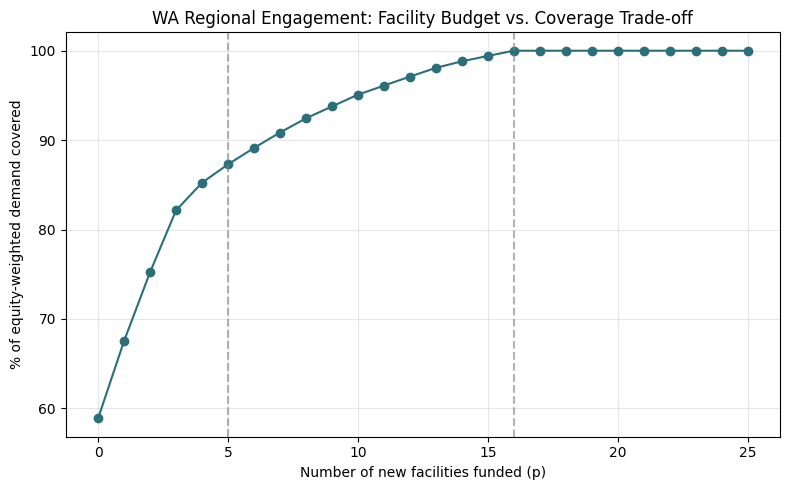


Saved chart -> outputs/budget_sensitivity_chart.png


In [14]:
cols = ['SA2_NAME', 'population', 'irsd_score', 'volunteer_rate', 'dist_to_nearest_crc_km',
        'weighted_demand', 'large_remote_flag']

scenario_5, y5 = solve_mclp(5)
scenario_16, y16 = solve_mclp(16)

print("=== Phase 1: Quick wins (5 new sites) ===")
print(rest.iloc[scenario_5][cols].sort_values('weighted_demand', ascending=False).to_string(index=False))

print("\n=== Full rollout (16 new sites -> 100% coverage) ===")
print(rest.iloc[scenario_16][cols].sort_values('weighted_demand', ascending=False).to_string(index=False))

rest['recommended_phase1'] = rest.index.isin(scenario_5)
rest['recommended_full'] = rest.index.isin(scenario_16)
rest['covered_full_rollout'] = y16
rest.to_csv(DATA_PROCESSED / "rest_of_wa_demand_analysis.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve_df['p'], curve_df['pct_coverage'], marker='o', color='#2a6f7a')
ax.axvline(5, color='gray', linestyle='--', alpha=0.6)
ax.axvline(16, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel('Number of new facilities funded (p)')
ax.set_ylabel('% of equity-weighted demand covered')
ax.set_title('WA Regional Engagement: Facility Budget vs. Coverage Trade-off')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PROCESSED.parent.parent / "outputs" / "budget_sensitivity_chart.png", dpi=150)
plt.show()
print("\nSaved chart -> outputs/budget_sensitivity_chart.png")
